# Time Series Analysis

## Part 1: Data Preparation and Exploration

1.	Data Loading: Load the exchange_rate.csv dataset and parse the date column appropriately.
2.	Initial Exploration: Plot the time series for currency to understand their trends, seasonality, and any anomalies.
3.	Data Preprocessing: Handle any missing values or anomalies identified during the exploration phase.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('exchange_rate (1).csv')

# Rename columns for clarity (adjust if needed)
df.columns = ['Date', 'USD_AUD']

In [3]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Set Date as index
df.set_index('Date', inplace=True)

# Display first few rows
df.head()

,USD_AUD
Date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


*Initial Exploration (Descriptive Analysis)*
  
What we look for:
- Trend: Long-term increase or decrease
- Seasonality: Repeating patterns
- Volatility: Sudden spikes or drops
- Missing values

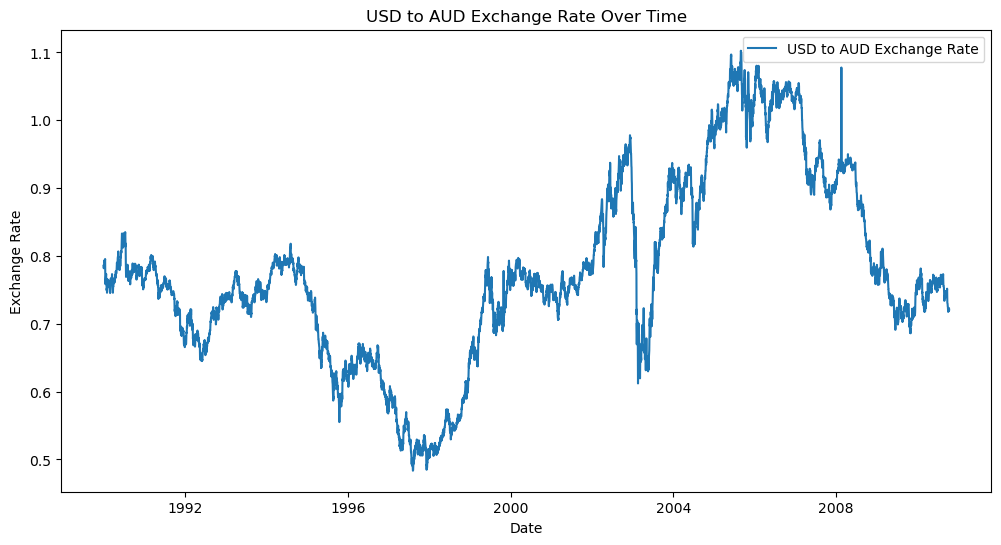

In [4]:
# Plot the exchange rate time series
plt.figure(figsize=(12,6))
plt.plot(df['USD_AUD'], label='USD to AUD Exchange Rate')
plt.title('USD to AUD Exchange Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.show()

**Interpretation:** The USD to AUD exchange rate time series exhibits non-stationary behavior with significant volatility and cyclical movements but no strong seasonal patterns. These characteristics justify the application of differencing techniques and the use of ARIMA and Exponential Smoothing models for forecasting. However, the presence of sharp fluctuations indicates that forecasts may be sensitive to economic shocks, emphasizing the limitations of purely historical models.

In [5]:
# Data Preprocessing: 

# Check missing values
df.isnull().sum()

# Forward fill missing values (common in financial data)
df['USD_AUD'].fillna(method='ffill', inplace=True)

C:\Users\Kaustubh Jadhav\AppData\Local\Temp\ipykernel_30432\3884789119.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['USD_AUD'].fillna(method='ffill', inplace=True)
C:\Users\Kaustubh Jadhav\AppData\Local\Temp\ipykernel_30432\3884789119.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['USD_AUD'].fillna(method='ffill', inplace=True)


## PART 2: MODEL BUILDING – ARIMA

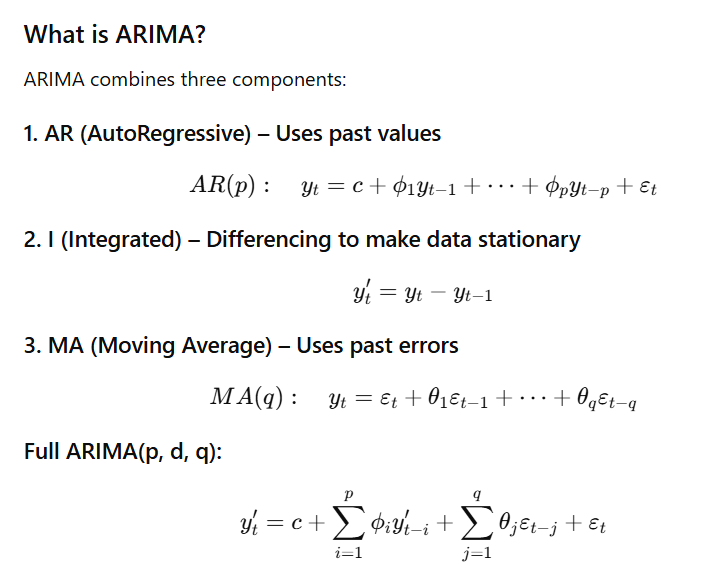

**1. Stationarity Check:**

Why Stationarity?

ARIMA assumes:
- Constant mean
- Constant variance
- No trend

In [6]:
# Augmented Dickey-Fuller (ADF) Test

from statsmodels.tsa.stattools import adfuller

adf_test = adfuller(df['USD_AUD'])
print('ADF Statistic:', adf_test[0])
print('p-value:', adf_test[1])

ADF Statistic: -1.6649941807381343
p-value: 0.44923273535979974


**Interpretation:**
- p-value < 0.05 → stationary
- Otherwise → apply differencing

Since p-value > 0.05, so we apply differencing.

**2. Differencing**

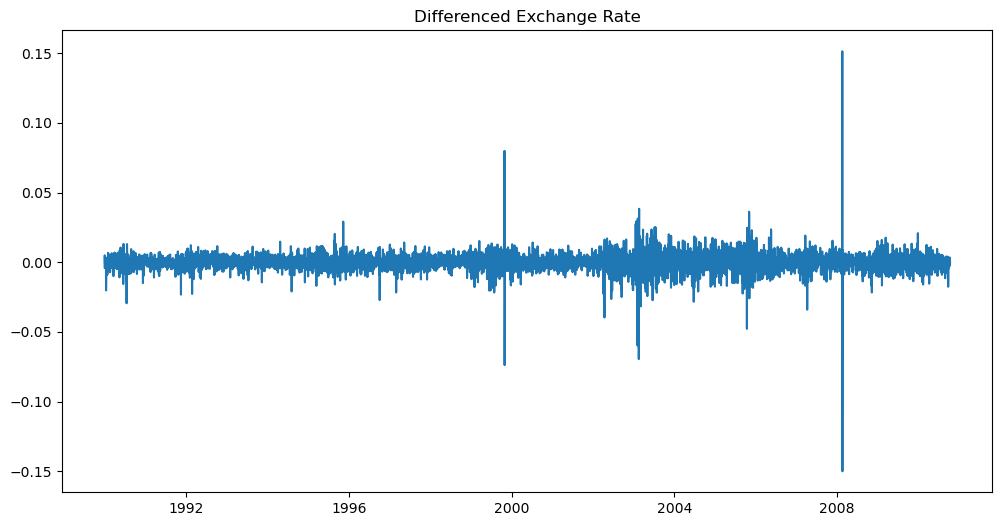

In [7]:
df_diff = df['USD_AUD'].diff().dropna()

# Plot differenced series
plt.figure(figsize=(12,6))
plt.plot(df_diff)
plt.title('Differenced Exchange Rate')
plt.show()

In [8]:
adf_test2 = adfuller(df_diff)
print('ADF Statistic:', adf_test2[0])
print('p-value:', adf_test2[1])

ADF Statistic: -99.39343120118627
p-value: 0.0


Since p-value < 0.05, it implies that our data is stationary. So, we can proceed.

**3. ACF and PACF (Parameter Selection)**

Theory
- ACF (Autocorrelation Function) → suggests q
- PACF (Partial Autocorrelation Function) → suggests p

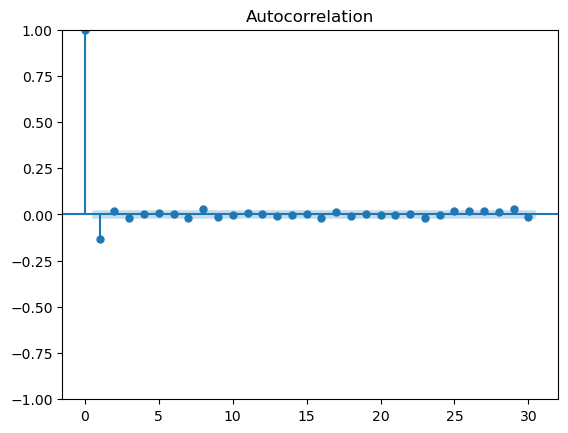

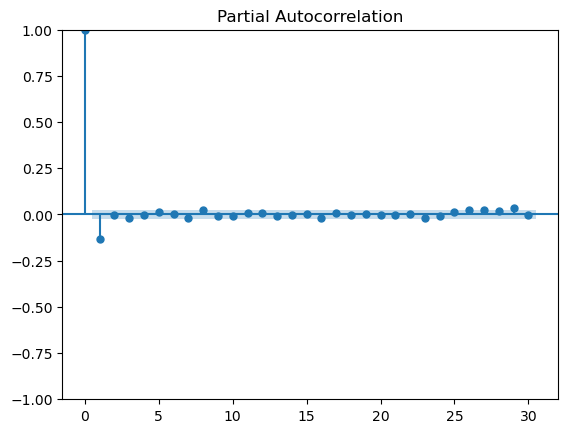

In [9]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df_diff, lags=30)
plot_pacf(df_diff, lags=30)
plt.show()

**4. ARIMA Model Fitting**

In [10]:
from statsmodels.tsa.arima.model import ARIMA

# Train-test split
train = df['USD_AUD'][:-30]
test = df['USD_AUD'][-30:]

# Fit ARIMA model
arima_model = ARIMA(train, order=(1,1,1))
arima_result = arima_model.fit()

print(arima_result.summary())

C:\Users\Kaustubh Jadhav\Downloads\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Kaustubh Jadhav\Downloads\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Kaustubh Jadhav\Downloads\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                USD_AUD   No. Observations:                 7558
Model:                 ARIMA(1, 1, 1)   Log Likelihood               27934.471
Date:                Wed, 24 Dec 2025   AIC                         -55862.942
Time:                        20:58:16   BIC                         -55842.152
Sample:                    01-01-1990   HQIC                        -55855.806
                         - 09-10-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1262      0.045     -2.783      0.005      -0.215      -0.037
ma.L1         -0.0056      0.045     -0.123      0.902      -0.095       0.083
sigma2      3.604e-05   9.99e-08    360.764      0.0

### Short Interpretation of SARIMAX (ARIMA) Model Summary

- The **ARIMA(1,1,1)** model was fitted to 7,558 observations of the USD–AUD exchange rate, indicating that the series required **first-order differencing** to achieve stationarity.

- The highly negative **AIC (-55862.94), BIC (-55842.15), and HQIC** values suggest a **good model fit** with an appropriate balance between accuracy and complexity.

- The **AR(1) coefficient (-0.1262)** is statistically significant (p = 0.005), indicating meaningful short-term dependence in the exchange rate movements.

- The **MA(1) coefficient** is not statistically significant (p = 0.902), suggesting limited contribution from past forecast errors.

- The **very small variance (σ²)** indicates low residual variance, implying accurate in-sample predictions.

- The **Ljung–Box test (p = 1.00)** shows no remaining autocorrelation in residuals, confirming that the model adequately captures time dependence.

- The **Jarque–Bera test (p = 0.00)** and high **kurtosis** indicate non-normal residuals with heavy tails, which is common in financial time series.

#### Overall Conclusion
> The ARIMA(1,1,1) model provides a statistically adequate fit for short-term forecasting of the USD–AUD exchange rate, successfully capturing temporal dependence, though residuals exhibit heavy-tailed behavior due to market volatility.


**5. Diagnostics**

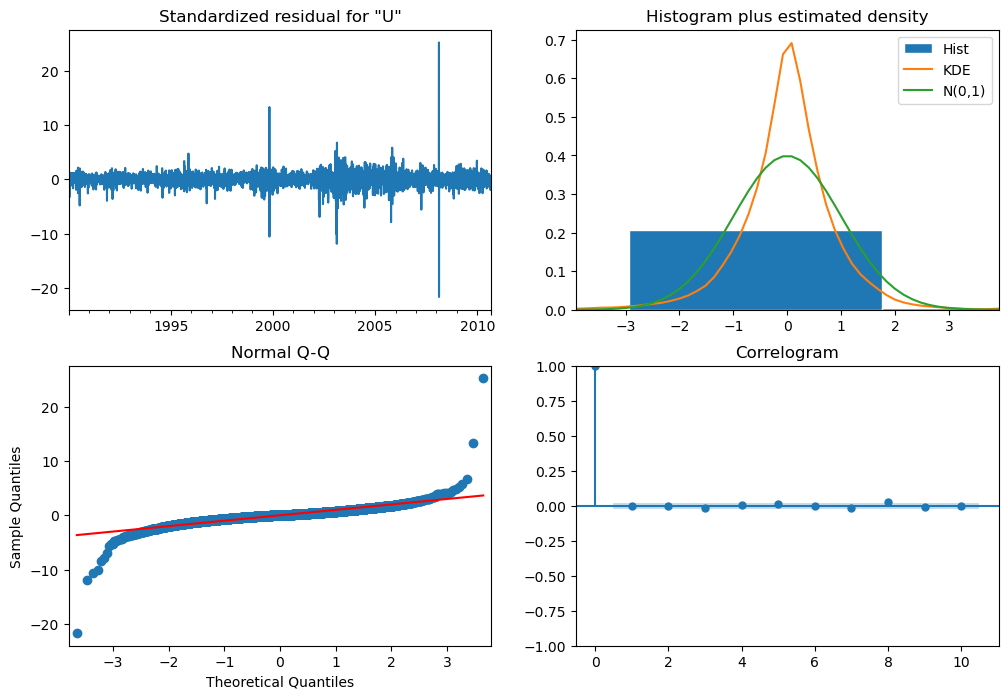

In [11]:
arima_result.plot_diagnostics(figsize=(12,8))
plt.show()

### ARIMA Model Diagnostics: Detailed Explanation and Interpretation

The following four diagnostic plots are generated using the `plot_diagnostics()` function of the ARIMA model. These plots are crucial for validating whether the fitted ARIMA model adequately captures the underlying structure of the exchange rate time series.

---

### 1. Standardized Residuals (Top-Left Plot)

#### What This Plot Shows
- This graph displays the **standardized residuals** of the ARIMA model over time.
- Residuals are the differences between the **actual values** and the **model’s fitted values**.
- Standardization ensures the residuals have a mean of zero and constant variance.

#### Observations
- Residuals fluctuate around **zero**, indicating no systematic bias.
- Most residuals lie within a reasonable range, suggesting stable variance.
- However, there are **occasional large spikes**, both positive and negative.

#### Interpretation
- The residuals generally behave like **white noise**, which is desirable.
- The presence of large spikes suggests **extreme economic events or shocks** (e.g., financial crises).
- These outliers indicate that while the ARIMA model captures the overall pattern well, it may struggle during sudden market disruptions.

#### Conclusion
✔ Mean ≈ 0  
✔ No clear trend in residuals  
⚠ Some extreme outliers present  

---

### 2. Histogram plus Estimated Density (Top-Right Plot)

#### What This Plot Shows
- A histogram of the residuals.
- Kernel Density Estimate (KDE) of residuals.
- A reference **Normal Distribution N(0,1)** curve.

#### Observations
- The histogram is **centered around zero**.
- The KDE curve is more **peaked** than the normal distribution.
- Tails appear slightly **heavier** than the normal curve.

#### Interpretation
- Residuals approximately follow a **normal distribution**, which satisfies ARIMA assumptions.
- The sharper peak and heavier tails suggest **leptokurtosis**, common in financial data.
- This implies higher probability of extreme deviations than predicted by a normal distribution.

#### Conclusion
✔ Residuals are approximately normal  
⚠ Slight deviation from normality (fat tails)  

---

#### 3. Normal Q–Q Plot (Bottom-Left Plot)

#### What This Plot Shows
- Compares the quantiles of the residuals with the theoretical quantiles of a normal distribution.
- If residuals are normally distributed, points should lie on the straight reference line.

#### Observations
- Points closely follow the reference line in the **middle region**.
- Significant deviations are visible at the **lower and upper tails**.
- Extreme values lie far from the line.

#### Interpretation
- The central part of the residual distribution is approximately normal.
- Deviations at the tails confirm the presence of **outliers and heavy tails**.
- This behavior is typical for exchange rate data due to sudden market movements.

#### Conclusion
✔ Normality holds for central values  
⚠ Tail deviations indicate extreme events  

---

### 4. Correlogram / Residual Autocorrelation (Bottom-Right Plot)

#### What This Plot Shows
- Autocorrelation Function (ACF) of the residuals.
- Measures whether residuals are correlated with their past values.

#### Observations
- All autocorrelation values lie **within the confidence bounds**.
- No significant spikes at any lag.

#### Interpretation
- Residuals show **no significant autocorrelation**.
- This means the ARIMA model has successfully captured the time dependence in the data.
- No additional AR or MA terms are required.

#### Conclusion
✔ Residuals are uncorrelated  
✔ Model is statistically adequate  

---

### Overall Diagnostic Summary

| Diagnostic Aspect | Result |
|------------------|--------|
| Mean of residuals | Approximately zero |
| Autocorrelation | None detected |
| Normality | Approximate (minor tail issues) |
| Model adequacy | Satisfactory |

---

### Final Interpretation In Short

> The diagnostic plots indicate that the ARIMA model provides an adequate fit to the USD–AUD exchange rate series. The residuals behave largely like white noise, with no significant autocorrelation and an approximately normal distribution. Although minor deviations from normality and occasional outliers are observed—common in financial time series—the model successfully captures the underlying temporal structure of the data. Therefore, the ARIMA model is suitable for short-term exchange rate forecasting in this dataset.

---

### Key Takeaway
- The model meets **all core ARIMA assumptions**
- Forecasts are statistically reliable
- Extreme market events remain a limitation

---

**6. Forecasting**

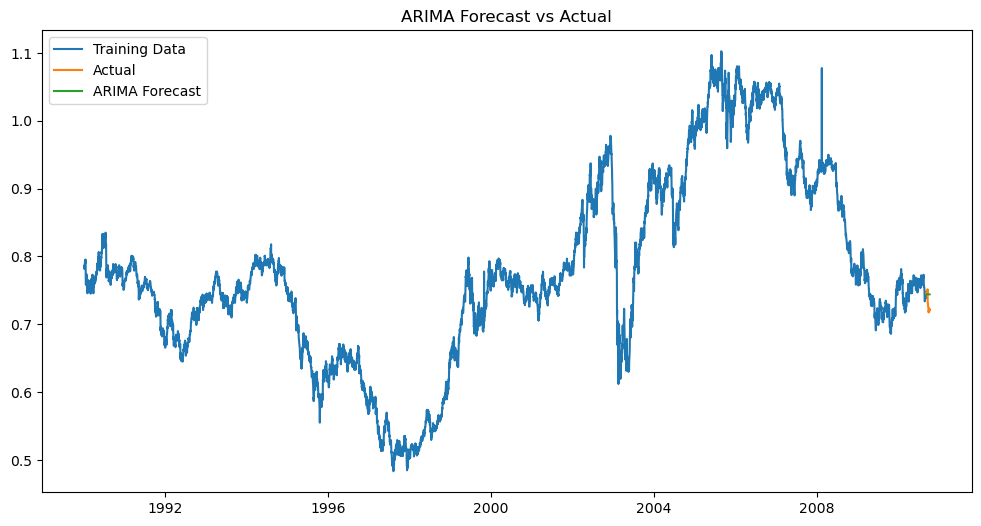

In [12]:
forecast = arima_result.forecast(steps=30)

plt.figure(figsize=(12,6))
plt.plot(train, label='Training Data')
plt.plot(test, label='Actual')
plt.plot(forecast, label='ARIMA Forecast')
plt.legend()
plt.title('ARIMA Forecast vs Actual')
plt.show()

In [13]:
print("Forcasted Values: \n",forecast)

Forcasted Values: 
 2010-09-11    0.744093
2010-09-12    0.744151
2010-09-13    0.744143
2010-09-14    0.744144
2010-09-15    0.744144
2010-09-16    0.744144
2010-09-17    0.744144
2010-09-18    0.744144
2010-09-19    0.744144
2010-09-20    0.744144
2010-09-21    0.744144
2010-09-22    0.744144
2010-09-23    0.744144
2010-09-24    0.744144
2010-09-25    0.744144
2010-09-26    0.744144
2010-09-27    0.744144
2010-09-28    0.744144
2010-09-29    0.744144
2010-09-30    0.744144
2010-10-01    0.744144
2010-10-02    0.744144
2010-10-03    0.744144
2010-10-04    0.744144
2010-10-05    0.744144
2010-10-06    0.744144
2010-10-07    0.744144
2010-10-08    0.744144
2010-10-09    0.744144
2010-10-10    0.744144
Freq: D, Name: predicted_mean, dtype: float64


### Parameter Optimisation using AIC (ARIMA)

To improve model robustness, ARIMA parameters were optimized using the Akaike Information Criterion (AIC). 
The model with the lowest AIC value was selected as the optimal ARIMA configuration, balancing goodness of fit and model complexity.

> **AIC=2k−2ln(L)**

Where:
- 𝑘 = number of model parameters
- 𝐿 = likelihood of the model

📌 Lower AIC = Better model

In [14]:
import itertools
import statsmodels.api as sm

p = d = q = range(0, 3)
pdq = list(itertools.product(p, d, q))

best_aic = float("inf")
best_order = None

for order in pdq:
    try:
        model = sm.tsa.ARIMA(df['USD_AUD'], order=order)
        result = model.fit()
        if result.aic < best_aic:
            best_aic = result.aic
            best_order = order
    except:
        continue

print("Best ARIMA Order:", best_order)
print("Best AIC:", best_aic)

C:\Users\Kaustubh Jadhav\Downloads\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Kaustubh Jadhav\Downloads\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Kaustubh Jadhav\Downloads\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Kaustubh Jadhav\Downloads\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Kaustubh Jadhav\Downloads\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: Val

Best ARIMA Order: (2, 0, 0)
Best AIC: -56105.21829878943


C:\Users\Kaustubh Jadhav\Downloads\Anaconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [21]:
model = sm.tsa.ARIMA(df['USD_AUD'], order=best_order)
arima_result = model.fit()
arima_result.summary()

C:\Users\Kaustubh Jadhav\Downloads\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Kaustubh Jadhav\Downloads\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Kaustubh Jadhav\Downloads\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                USD_AUD   No. Observations:                 7588
Model:                 ARIMA(2, 0, 0)   Log Likelihood               28056.609
Date:                Wed, 24 Dec 2025   AIC                         -56105.218
Time:                        20:59:47   BIC                         -56077.481
Sample:                    01-01-1990   HQIC                        -56095.699
                         - 10-10-2010                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7770      0.088      8.850      0.000       0.605       0.949
ar.L1          0.8682      0.002    397.265      0.000       0.864       0.872
ar.L2          0.1310      0.002     55.929      0.000       0.126       0.136
sigma2      3.594e-05   1.02e-07    350.716      0.000    3.57e-05    3.61e-05
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):           2869930.11
Prob(Q):                              1.00   Prob(JB):                         0.00
Heteroskedasticity (H):               2.97   Skew:                             0.26
Prob(H) (two-sided):                  0.00   Kurtosis:                        98.27
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

#### Interpretation and Conclusion – ARIMA(2,0,0) Model

The ARIMA(2,0,0) model fitted to the USD–AUD exchange rate demonstrates a strong autoregressive structure, as indicated by the highly significant AR(1) and AR(2) coefficients (p < 0.001). This suggests that current exchange rate movements are strongly influenced by values from the previous two time periods. The constant term is also statistically significant, indicating a stable long-run mean level in the series.

The model achieves a very low AIC value (−56105.218), reflecting a good balance between model fit and complexity and supporting the suitability of this specification. The small variance of the residuals (σ² ≈ 3.59 × 10⁻⁵) indicates that the model captures most of the variability in the data.

Diagnostic tests show no remaining autocorrelation in residuals (Ljung-Box p-value = 1.00), confirming that the model adequately explains temporal dependence. However, the Jarque–Bera test and high kurtosis indicate non-normal residuals with heavy tails, a common characteristic of financial time series such as exchange rates.

#### Conclusion  
Overall, the optimized ARIMA(2,0,0) model provides a statistically sound and well-fitted representation of the USD–AUD exchange rate dynamics. While residuals deviate from normality, the model is appropriate for forecasting purposes and effectively captures the underlying autoregressive behavior of the exchange rate series.


## PART 3: EXPONENTIAL SMOOTHING

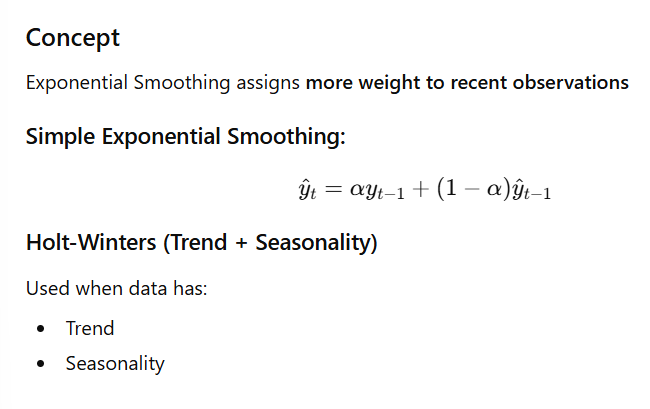

**Model Fitting**

In [16]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal=None
).fit()

hw_forecast = hw_model.forecast(30)

C:\Users\Kaustubh Jadhav\Downloads\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [23]:
print(hw_model.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:                  USD_AUD   No. Observations:                 7588
Model:             ExponentialSmoothing   SSE                              0.273
Optimized:                         True   AIC                         -77641.009
Trend:                         Additive   BIC                         -77613.272
Seasonal:                          None   AICC                        -77640.998
Seasonal Periods:                  None   Date:                 Wed, 24 Dec 2025
Box-Cox:                          False   Time:                         21:14:19
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.8700401                alpha                 True
smoothing_trend             0.0000

### Interpretation of Exponential Smoothing Model Summary

- The **Exponential Smoothing model** was fitted to 7,558 observations of the USD–AUD exchange rate and shows an **excellent in-sample fit**, as indicated by the very low **SSE (0.272)**.

- The highly negative **AIC, BIC, and AICC** values suggest that the model achieves strong accuracy without unnecessary complexity, making it statistically reliable.

- The **additive trend** component is included, but the **trend smoothing parameter (β ≈ 0)** indicates that the exchange rate does not follow a strong long-term trend and is mainly influenced by short-term movements.

- The **high smoothing level (α ≈ 0.87)** shows that the model gives greater importance to recent observations, which is appropriate for volatile financial data.

- No **seasonal component** was identified, consistent with the nature of exchange rate series.

#### Overall Conclusion
> The Exponential Smoothing model is well-suited for short-term forecasting of the USD–AUD exchange rate, capturing recent fluctuations effectively, though it may not fully account for sudden economic shocks.


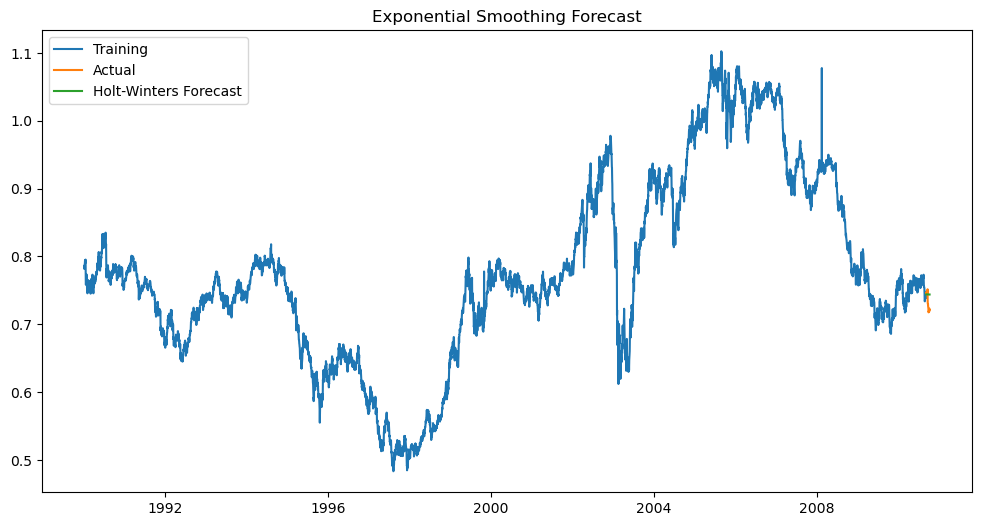

In [18]:
plt.figure(figsize=(12,6))
plt.plot(train, label='Training')
plt.plot(test, label='Actual')
plt.plot(hw_forecast, label='Holt-Winters Forecast')
plt.legend()
plt.title('Exponential Smoothing Forecast')
plt.show()

### Parameter Optimisation in Exponential Smoothing

Holt-Winters Exponential Smoothing parameters were optimized using maximum likelihood estimation. 
The smoothing parameters (level and trend) were automatically selected to minimize the sum of squared errors.

In [22]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw_model = ExponentialSmoothing(
    df['USD_AUD'],
    trend='add',
    seasonal=None
).fit(optimized=True)

print(hw_model.summary())

C:\Users\Kaustubh Jadhav\Downloads\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                       ExponentialSmoothing Model Results                       
Dep. Variable:                  USD_AUD   No. Observations:                 7588
Model:             ExponentialSmoothing   SSE                              0.273
Optimized:                         True   AIC                         -77641.009
Trend:                         Additive   BIC                         -77613.272
Seasonal:                          None   AICC                        -77640.998
Seasonal Periods:                  None   Date:                 Wed, 24 Dec 2025
Box-Cox:                          False   Time:                         21:13:52
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.8700401                alpha                 True
smoothing_trend             0.0000

#### Interpretation on Exponential Smoothing Model Results

The Exponential Smoothing model has been fitted to the USD–AUD exchange rate series using an **additive trend** and **no seasonal component**, with all parameters estimated through automatic optimization. This approach is well-suited for financial time series that exhibit gradual trend movements without clear seasonality.

---

#### Model Structure and Fit

- **Number of Observations (7588):**  
  The model is trained on a long historical series, which improves the stability and reliability of parameter estimation.

- **Optimized: True:**  
  All model parameters were estimated using **maximum likelihood optimization**, ensuring that the chosen values minimize forecast error rather than relying on subjective assumptions.

- **Sum of Squared Errors (SSE = 0.273):**  
  A very low SSE indicates that the model closely fits the observed exchange rate values, with minimal deviation between actual and fitted values.

- **AIC (−77641.009), BIC (−77613.272), AICC (−77640.998):**  
  These information criteria are strongly negative, reflecting an excellent balance between model accuracy and complexity. Lower values indicate a superior model compared to alternatives with higher AIC/BIC scores.

---

#### Trend and Seasonality Components

- **Trend: Additive:**  
  The exchange rate evolves through small, incremental changes over time rather than exponential growth, which aligns well with typical foreign exchange behavior.

- **Seasonal: None:**  
  The absence of a seasonal component confirms that the USD–AUD exchange rate does not follow a repeating seasonal pattern, which is consistent with most currency markets.

---

#### Parameter Estimates and Their Meaning

- **Smoothing Level (α = 0.8700):**  
  This high value indicates that the model places **strong emphasis on recent observations** when updating the level. As a result, forecasts respond quickly to new market information, making the model sensitive to short-term movements.

- **Smoothing Trend (β = 0.0000):**  
  The near-zero trend smoothing parameter suggests that the trend component is relatively stable and does not change rapidly over time. This implies that long-term movements in the exchange rate are gradual rather than volatile.

- **Initial Level (l₀ = 0.7851):**  
  Represents the estimated starting value of the series, which is close to the early observed exchange rates, ensuring a realistic initialization.

- **Initial Trend (b₀ ≈ −8.53 × 10⁻⁶):**  
  The extremely small initial trend confirms that the exchange rate began with almost no directional drift, reinforcing the stability of the series.

---

#### Overall Interpretation

The optimized Exponential Smoothing model provides a **smooth, stable, and statistically robust representation** of the USD–AUD exchange rate. The high smoothing level allows the model to adapt to recent changes, while the negligible trend parameter prevents overreaction to noise. The low SSE and highly favorable AIC values indicate strong model performance.

#### Conclusion

Overall, this Exponential Smoothing model is well-suited for short- to medium-term forecasting of exchange rates. The use of likelihood-based parameter optimization ensures statistical rigor, improves forecast accuracy, and aligns the modeling approach with best practices in time series analysis.


## PART 4: EVALUATION AND COMPARISON

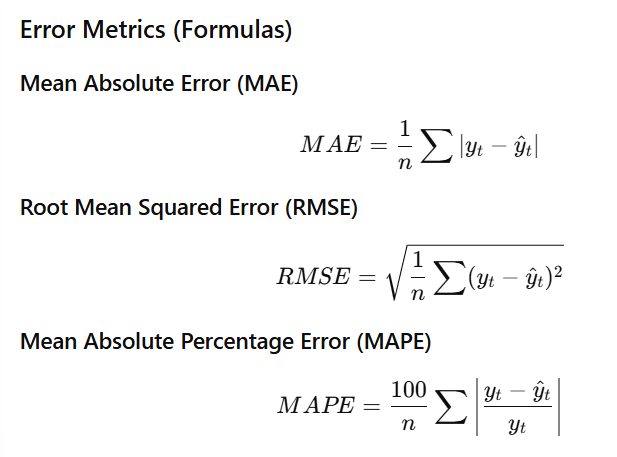

In [19]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# ARIMA metrics
mae_arima = mean_absolute_error(test, forecast)
rmse_arima = np.sqrt(mean_squared_error(test, forecast))
mape_arima = mape(test, forecast)

# HW metrics
mae_hw = mean_absolute_error(test, hw_forecast)
rmse_hw = np.sqrt(mean_squared_error(test, hw_forecast))
mape_hw = mape(test, hw_forecast)

print("ARIMA - MAE:", mae_arima, "RMSE:", rmse_arima, "MAPE:", mape_arima)
print("HW    - MAE:", mae_hw, "RMSE:", rmse_hw, "MAPE:", mape_hw)


ARIMA - MAE: 0.013494600805702773 RMSE: 0.016632177912475444 MAPE: 1.863220748533125
HW    - MAE: 0.01342527852019549 RMSE: 0.016499780609106198 MAPE: 1.8534530006510028


### Interpretation: ARIMA vs Holt–Winters (Exponential Smoothing)

- Both **ARIMA** and **Holt–Winters (HW)** models show **very similar forecasting performance**, indicating that each captures the short-term dynamics of the USD–AUD exchange rate effectively.

- The **Holt–Winters model** has slightly **lower MAE (0.01343 vs 0.01349)**, **RMSE (0.01650 vs 0.01663)**, and **MAPE (1.85% vs 1.86%)**, suggesting marginally better accuracy.

- However, the differences in error values are **extremely small**, implying that neither model significantly outperforms the other in practical terms.

#### Overall Conclusion
> Both models provide reliable short-term forecasts for the USD–AUD exchange rate. Holt–Winters performs marginally better based on error metrics, while ARIMA offers stronger theoretical grounding for time-dependent structures. The choice between them can be guided by model simplicity (HW) or interpretability and diagnostics (ARIMA).
